In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel("marketing_campaign.xlsx")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


In [7]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
df['Income'].fillna(df['Income'].median(), inplace=True)
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Customer_Tenure'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

df['Age'] = 2026 - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts',
                            'MntGoldProds']].sum(axis=1)

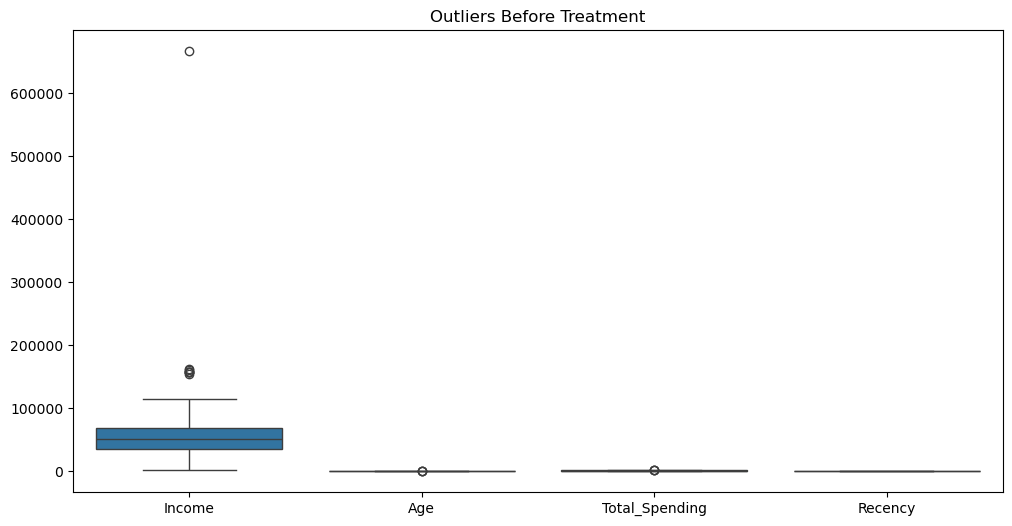

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income','Age','Total_Spending','Recency']])
plt.title("Outliers Before Treatment")
plt.show()

In [13]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

for col in ['Income','Age','Total_Spending','Recency']:
    df = remove_outliers_iqr(df, col)

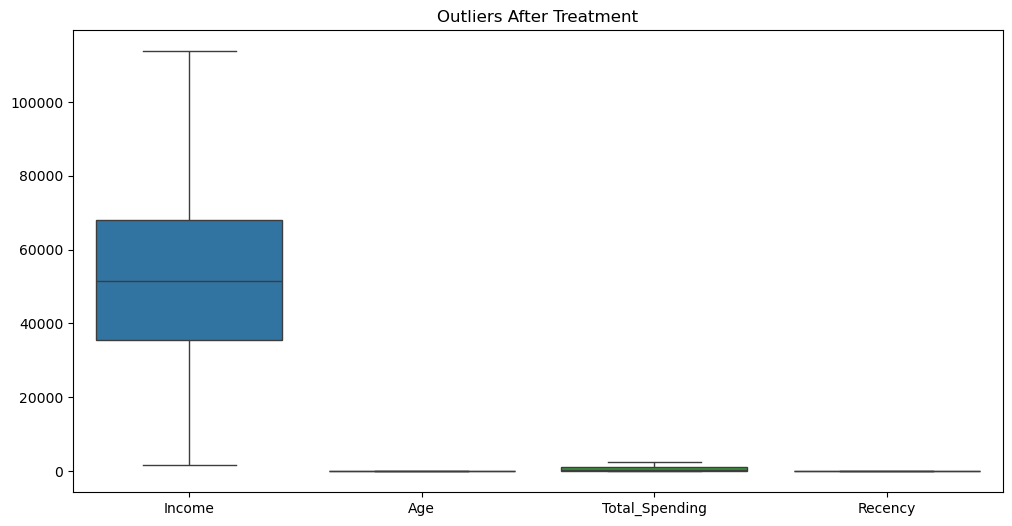

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Income','Age','Total_Spending','Recency']])
plt.title("Outliers After Treatment")
plt.show()

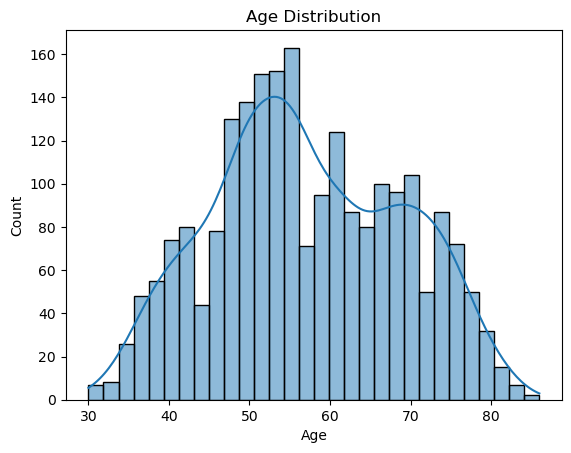

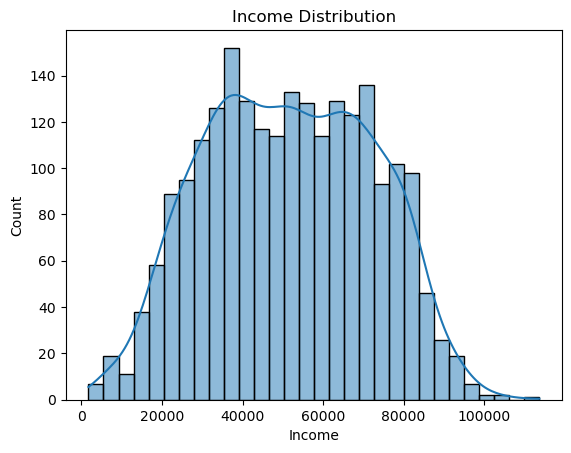

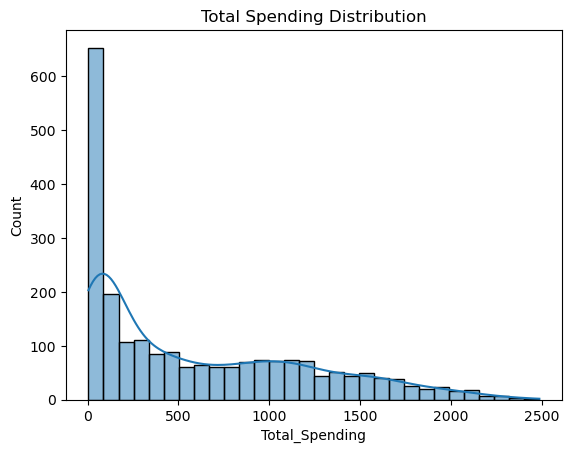

In [15]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

sns.histplot(df['Total_Spending'], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

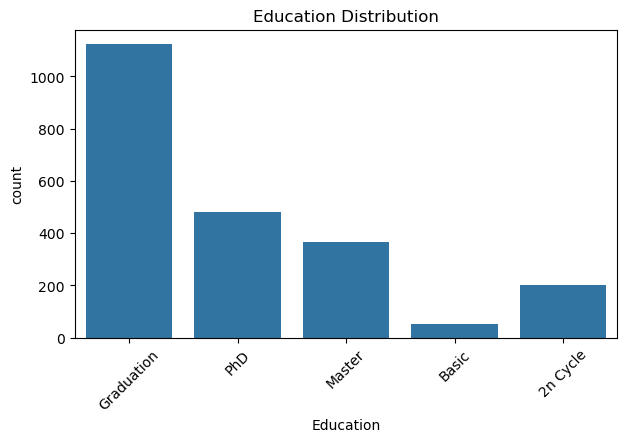

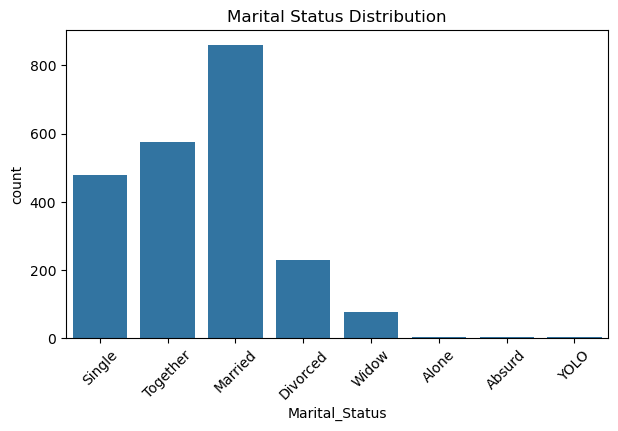

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(x='Education', data=df)
plt.xticks(rotation=45)
plt.title("Education Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(x='Marital_Status', data=df)
plt.xticks(rotation=45)
plt.title("Marital Status Distribution")
plt.show()

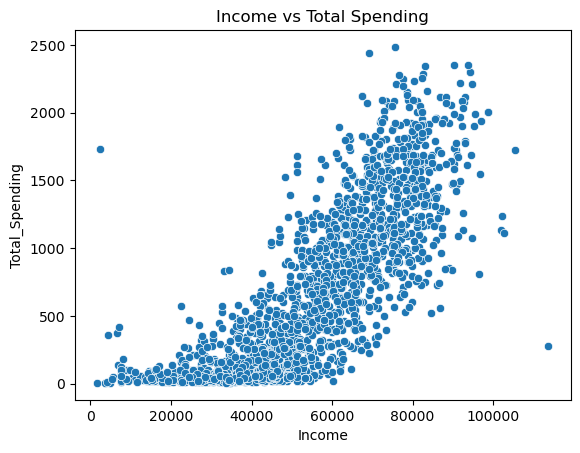

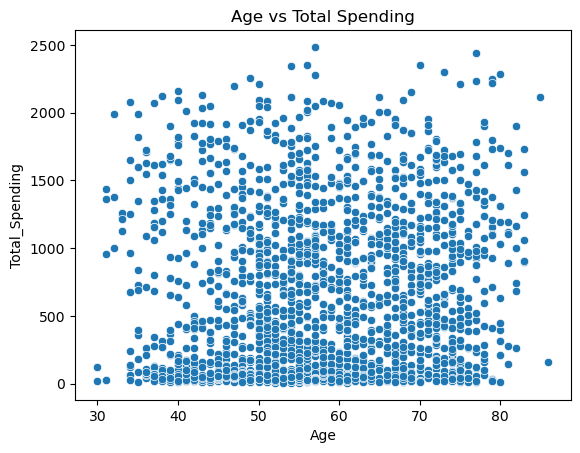

In [17]:
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title("Income vs Total Spending")
plt.show()

sns.scatterplot(x='Age', y='Total_Spending', data=df)
plt.title("Age vs Total Spending")
plt.show()

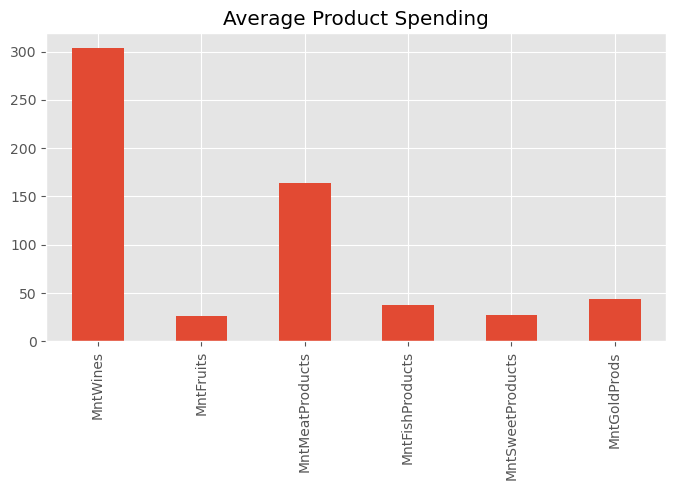

In [22]:
product_cols = ['MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds']

df[product_cols].mean().plot(kind='bar', figsize=(8,4))
plt.title("Average Product Spending")
plt.show()

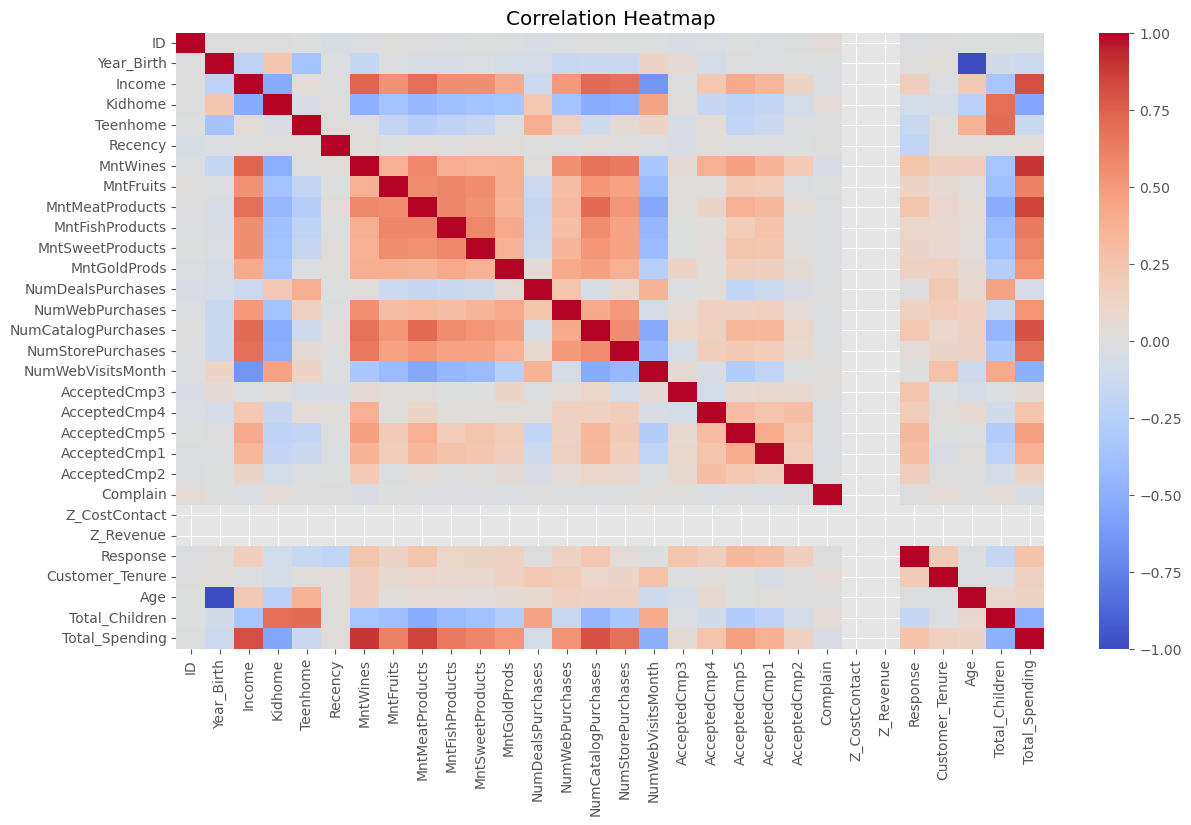

In [23]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
scale_features = ['Age','Income','Recency','Total_Spending',
                  'NumWebPurchases','NumStorePurchases',
                  'NumCatalogPurchases','Customer_Tenure']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[scale_features])

df_scaled = pd.DataFrame(df_scaled, columns=scale_features)
df_scaled.head()

,Age,Income,Recency,Total_Spending,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,Customer_Tenure
0,1.014839,0.319494,0.306764,1.698128,1.405082,-0.557672,2.639583,1.528030
1,1.271537,-0.254061,-0.384037,-0.964498,-1.116686,-1.174965,-0.584500,-1.191595
2,0.330310,0.974797,-0.798517,0.289783,1.405082,1.294209,-0.226268,-0.207585
3,-1.295446,-1.211995,-0.798517,-0.920958,-0.756433,-0.557672,-0.942731,-1.063030
4,-1.038748,0.327032,1.550205,-0.303028,0.324324,0.059622,0.131963,-0.954245


In [19]:
X = df.drop(columns=['ID','Dt_Customer','Response'])
y = df['Response']

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
y_pred = model.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.852017937219731


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       379
           1       0.52      0.18      0.27        67

    accuracy                           0.85       446
   macro avg       0.70      0.58      0.59       446
weighted avg       0.82      0.85      0.82       446



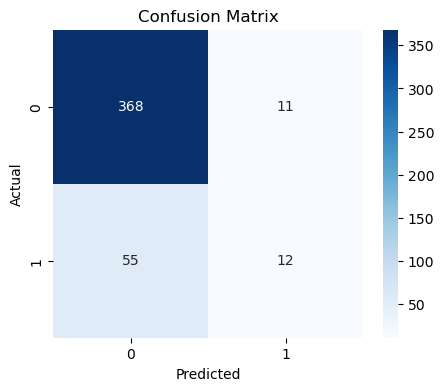

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()